# Logistic Regression — Training and Evaluation

This notebook trains a Logistic Regression classifier on the preprocessed Teen Mental Health dataset  
and evaluates its performance using metrics appropriate for imbalanced classification.

### Steps
1. Imports and configuration  
2. Load processed data  
3. Train the model  
4. Predictions and threshold tuning  
5. Evaluation metrics  
6. ROC and Precision-Recall curves  
7. Feature importance (coefficients)  
8. Summary  


---
## 1. Imports and Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path

# Modelling
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    f1_score,
)

# Visualization
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from IPython.display import display

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.figsize': (10, 5), 'axes.titlesize': 13, 'figure.dpi': 100})
pd.set_option('display.float_format', '{:.4f}'.format)

# -- Project root resolution -------------------------------------------------
def find_project_root(marker: str = 'requirements.txt') -> Path:
    for candidate in [Path.cwd()] + list(Path.cwd().parents):
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f"Could not find project root (missing '{marker}').")

PROJECT_ROOT  = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR   = PROJECT_ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

print(f'Project root : {PROJECT_ROOT}')
print('Imports complete.')

Project root : /Users/usuario/Desktop/logistic regression
Imports complete.


---
## 2. Load Processed Data

The processed files were generated by `02_preprocessing.ipynb`.  
Training set is SMOTE-balanced (935 vs 935). Test set preserves the original distribution (234 vs 6).

In [2]:
X_train = pd.read_csv(PROCESSED_DIR / 'X_train.csv')
X_test  = pd.read_csv(PROCESSED_DIR / 'X_test.csv')
y_train = pd.read_csv(PROCESSED_DIR / 'y_train.csv').squeeze()
y_test  = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze()

print('Data loaded successfully.')
print(f'  X_train : {X_train.shape}  |  class 0: {(y_train==0).sum()}  class 1: {(y_train==1).sum()}')
print(f'  X_test  : {X_test.shape}   |  class 0: {(y_test==0).sum()}   class 1: {(y_test==1).sum()}')
print(f'  Features: {list(X_train.columns)}')

Data loaded successfully.
  X_train : (1870, 13)  |  class 0: 935  class 1: 935
  X_test  : (240, 13)   |  class 0: 234   class 1: 6
  Features: ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level', 'gender', 'platform_usage_Instagram', 'platform_usage_TikTok', 'social_interaction_level']


---
## 3. Train the Model

Logistic Regression with `class_weight='balanced'` is used as an additional safeguard against  
class imbalance on top of SMOTE. `lbfgs` is the recommended solver for small-to-medium datasets.

In [3]:
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # additional penalty weight for minority class
    solver='lbfgs',
    random_state=RANDOM_STATE,
)

model.fit(X_train, y_train)

print('Model trained successfully.')
print(f'  Solver    : {model.solver}')
print(f'  Max iter  : {model.max_iter}')
print(f'  Converged : {model.n_iter_[0] < model.max_iter}  ({model.n_iter_[0]} iterations)')

Model trained successfully.


  Solver    : lbfgs
  Max iter  : 1000
  Converged : True  (18 iterations)


---
## 4. Predictions and Threshold Tuning

The default classification threshold is **0.5**: samples with predicted probability >= 0.5 are labeled as class 1.  
With a severely imbalanced test set (only 6 positive cases out of 240), a lower threshold may  
improve recall at the cost of precision. We evaluate both and choose the threshold that maximises F1.

In [4]:
# Predicted probabilities for class 1
y_prob = model.predict_proba(X_test)[:, 1]

# Find the threshold that maximises F1-score on the test set
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = [f1_score(y_test, (y_prob >= t).astype(int), zero_division=0) for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1        = max(f1_scores)

# Generate predictions using both thresholds for comparison
y_pred_default = model.predict(X_test)                          # threshold = 0.5
y_pred_tuned   = (y_prob >= best_threshold).astype(int)         # best F1 threshold

print(f'Default threshold (0.50) -> F1: {f1_score(y_test, y_pred_default, zero_division=0):.4f}')
print(f'Best threshold    ({best_threshold:.2f}) -> F1: {best_f1:.4f}')

Default threshold (0.50) -> F1: 0.5882
Best threshold    (0.82) -> F1: 0.7273


---
## 5. Evaluation Metrics

> **Why not accuracy?**  
> With 97.4% of samples in class 0, a naive model that always predicts 0 achieves 97.5% accuracy.  
> ROC-AUC, F1-score, and the confusion matrix give a far more honest picture of performance.

In [5]:
roc_auc = roc_auc_score(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

print('=' * 55)
print('  EVALUATION METRICS')
print('=' * 55)
print(f'  ROC-AUC Score          : {roc_auc:.4f}')
print(f'  Average Precision (AP) : {avg_precision:.4f}')
print()
print(f'  --- Default threshold (0.50) ---')
print(classification_report(y_test, y_pred_default,
                             target_names=['No Depression', 'Depression'],
                             zero_division=0))
print(f'  --- Tuned threshold ({best_threshold:.2f}) ---')
print(classification_report(y_test, y_pred_tuned,
                             target_names=['No Depression', 'Depression'],
                             zero_division=0))

  EVALUATION METRICS
  ROC-AUC Score          : 0.9922
  Average Precision (AP) : 0.8333

  --- Default threshold (0.50) ---
               precision    recall  f1-score   support

No Depression       1.00      0.97      0.98       234
   Depression       0.45      0.83      0.59         6

     accuracy                           0.97       240
    macro avg       0.73      0.90      0.79       240
 weighted avg       0.98      0.97      0.97       240

  --- Tuned threshold (0.82) ---
               precision    recall  f1-score   support

No Depression       0.99      1.00      0.99       234
   Depression       0.80      0.67      0.73         6

     accuracy                           0.99       240
    macro avg       0.90      0.83      0.86       240
 weighted avg       0.99      0.99      0.99       240



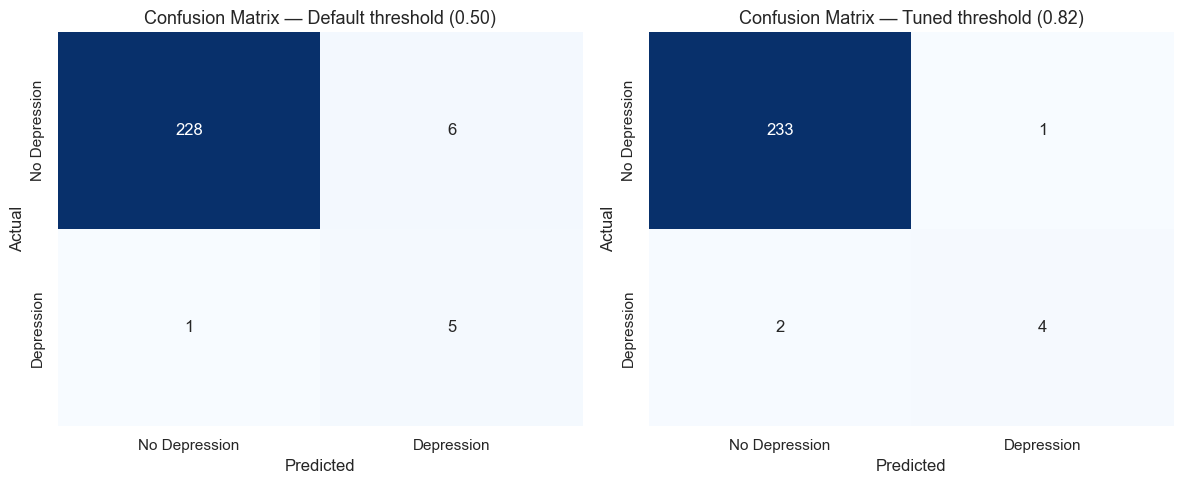

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_default, y_pred_tuned],
    [f'Confusion Matrix — Default threshold (0.50)',
     f'Confusion Matrix — Tuned threshold ({best_threshold:.2f})'],
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['No Depression', 'Depression'],
        yticklabels=['No Depression', 'Depression'],
        cbar=False,
    )
    ax.set_title(title)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '08_confusion_matrices.png', bbox_inches='tight')
plt.show()

---
## 6. ROC and Precision-Recall Curves

- **ROC curve**: plots True Positive Rate vs False Positive Rate across all thresholds. AUC = 1 is perfect.
- **Precision-Recall curve**: more informative than ROC for imbalanced datasets. A random classifier achieves AP equal to the class prevalence (2.6%).

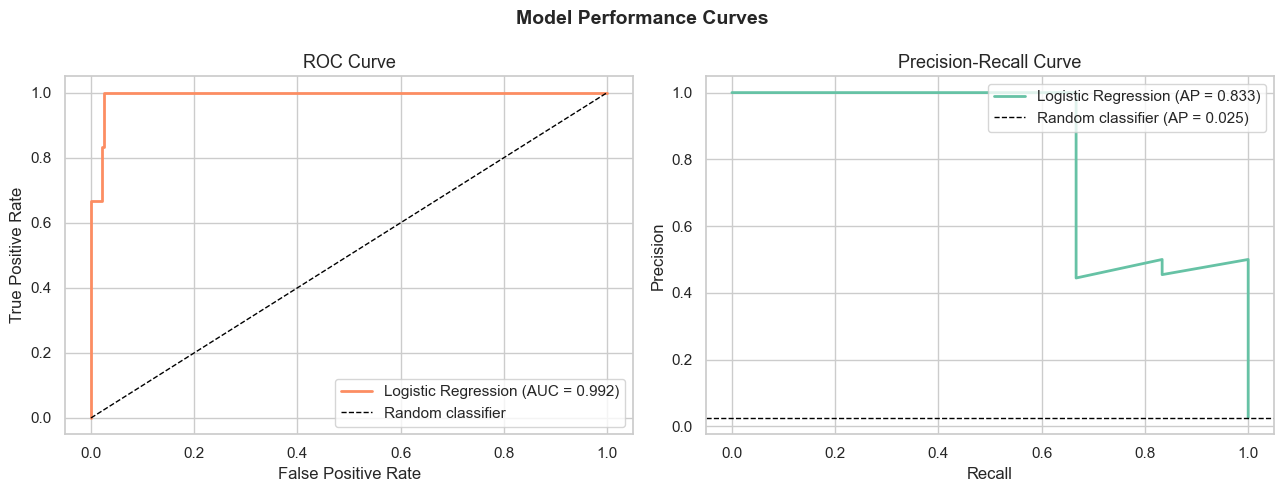

In [7]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
precision, recall, _ = precision_recall_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- ROC Curve ---------------------------------------------------------------
axes[0].plot(fpr, tpr, color=sns.color_palette('Set2')[1], lw=2,
             label=f'Logistic Regression (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')

# -- Precision-Recall Curve --------------------------------------------------
baseline = y_test.mean()  # prevalence of class 1
axes[1].plot(recall, precision, color=sns.color_palette('Set2')[0], lw=2,
             label=f'Logistic Regression (AP = {avg_precision:.3f})')
axes[1].axhline(baseline, color='k', linestyle='--', lw=1,
                label=f'Random classifier (AP = {baseline:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='upper right')

plt.suptitle('Model Performance Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '09_roc_pr_curves.png', bbox_inches='tight')
plt.show()

---
## 7. Feature Importance — Model Coefficients

In logistic regression, the magnitude of each coefficient indicates how strongly that feature  
influences the log-odds of the prediction. Positive coefficients increase the probability of class 1 (depression);  
negative coefficients decrease it.

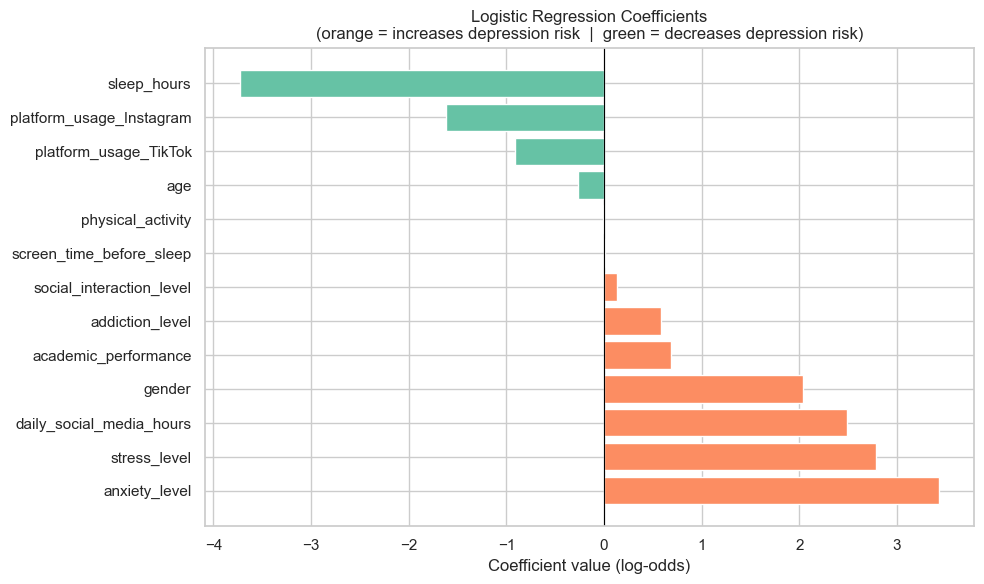


Coefficients (sorted by magnitude):


,feature,coefficient
0,sleep_hours,-3.7303
1,anxiety_level,3.4301
2,stress_level,2.7817
3,daily_social_media_hours,2.4878
4,gender,2.0374
5,platform_usage_Instagram,-1.6182
6,platform_usage_TikTok,-0.9104
7,academic_performance,0.6815
8,addiction_level,0.5860
9,age,-0.2712


In [8]:
coef_df = pd.DataFrame({
    'feature'    : X_train.columns,
    'coefficient': model.coef_[0],
}).sort_values('coefficient', ascending=False)

colors = [
    sns.color_palette('Set2')[1] if c > 0 else sns.color_palette('Set2')[0]
    for c in coef_df['coefficient']
]

plt.figure(figsize=(10, 6))
bars = plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient value (log-odds)')
plt.title('Logistic Regression Coefficients\n(orange = increases depression risk  |  green = decreases depression risk)',
          fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '10_feature_coefficients.png', bbox_inches='tight')
plt.show()

print('\nCoefficients (sorted by magnitude):')
display(coef_df.assign(abs_coef=coef_df['coefficient'].abs())
               .sort_values('abs_coef', ascending=False)
               .drop(columns='abs_coef')
               .reset_index(drop=True))

---
## 8. Summary

In [9]:
top_positive = coef_df[coef_df['coefficient'] > 0].head(3)['feature'].tolist()
top_negative = coef_df[coef_df['coefficient'] < 0].tail(3)['feature'].tolist()

print('=' * 60)
print('          MODEL SUMMARY')
print('=' * 60)
print(f'  Model              : Logistic Regression')
print(f'  Solver             : lbfgs')
print(f'  Class weight       : balanced')
print(f'  Training samples   : {len(X_train):,} (SMOTE balanced)')
print(f'  Test samples       : {len(X_test):,} (original distribution)')
print()
print('  Performance:')
print(f'    ROC-AUC           : {roc_auc:.4f}')
print(f'    Average Precision : {avg_precision:.4f}')
print(f'    Best F1 Score     : {best_f1:.4f}  (threshold = {best_threshold:.2f})')
print()
print('  Top features increasing depression risk:')
for f in top_positive:
    v = coef_df[coef_df['feature']==f]['coefficient'].values[0]
    print(f'    + {f:<30} {v:+.4f}')
print()
print('  Top features decreasing depression risk:')
for f in top_negative:
    v = coef_df[coef_df['feature']==f]['coefficient'].values[0]
    print(f'    - {f:<30} {v:+.4f}')
print('=' * 60)

          MODEL SUMMARY
  Model              : Logistic Regression
  Solver             : lbfgs
  Class weight       : balanced
  Training samples   : 1,870 (SMOTE balanced)
  Test samples       : 240 (original distribution)

  Performance:
    ROC-AUC           : 0.9922
    Average Precision : 0.8333
    Best F1 Score     : 0.7273  (threshold = 0.82)

  Top features increasing depression risk:
    + anxiety_level                  +3.4301
    + stress_level                   +2.7817
    + daily_social_media_hours       +2.4878

  Top features decreasing depression risk:
    - platform_usage_TikTok          -0.9104
    - platform_usage_Instagram       -1.6182
    - sleep_hours                    -3.7303
